# Budowanie, trenowanie i testowanie modelu

In [132]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path

# Dodanie dźwięku przy długich komórkach
import subprocess
def play_sound():
    sound_file = '/mnt/d/Backup/INZ/msg.ogg'
    subprocess.run(['ffplay', '-nodisp', '-autoexit', sound_file], capture_output=True)

Wczytanie odpowiednich danych

In [133]:
SAVE_DIR = Path("/mnt/d/Backup/MAGISTERSKIE/outputs/MODEL")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [149]:
df = pd.read_csv(str(SAVE_DIR)+'/df_training.csv')
ds = df.to_numpy()
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,J1,...,G1,G2,dJ1,dJ2,dJ3,dJ4,dJ5,dJ6,dG1,dG2
0,0.887936,-0.547135,-1.714233,0.245226,0.168362,-0.094620,0.068734,-0.365825,-0.408859,3.423105,...,0.603365,0.905047,-0.000294,0.000588,0.000294,-0.000527,0.001726,-0.002205,-0.005113,0.000000
1,5.740595,3.699372,1.486481,-0.934237,0.324639,-1.515793,-4.697986,4.002044,-0.703934,3.423105,...,0.603365,0.905047,0.000159,-0.000004,0.000163,-0.000479,0.000000,0.000048,-0.199417,0.184077
2,17.454743,-39.564632,-2.836090,9.539104,-49.189672,2.754837,6.457398,-41.429044,-0.676056,3.423105,...,0.603365,0.905047,0.093204,-0.124143,-0.149392,0.273528,-0.001677,0.093764,-0.184077,0.184077
3,14.490642,-67.658986,-2.444489,7.110606,-79.788809,0.834213,4.995761,-68.229255,-3.038773,3.423105,...,0.603365,0.905047,0.095104,-0.254979,-0.196972,0.451326,-0.002013,0.095922,-0.184077,0.184077
4,63.659213,-53.603594,6.255508,56.744645,-61.748530,17.750183,49.912400,-53.265646,11.136002,3.423105,...,0.603365,0.905047,0.325545,-0.229877,-0.061554,0.285608,-0.004554,0.326306,-0.199417,0.184077


# Wstępne Przetwarzanie Danych

Rozdzielenie danych na wejściowe i wyjściowe

In [141]:
x_ds = ds[:, 0:17] # 17 danych - 3*3Δxyz + 6*dJ + 2*dG
y_ds = ds[:, 17:]  # 8  danych - 6*pred_dJ + 2*pred_dG
print(x_ds.shape)
print(y_ds.shape)
print(x_ds[0])
print(y_ds[0])

(7812, 17)
(7812, 8)
[ 0.88793552 -0.54713482 -1.7142334   0.24522633  0.16836209 -0.09461975
  0.06873373 -0.36582538 -0.40885925  3.423105    1.230969    1.932432
  1.527801    1.58762     2.663374    0.603365    0.905047  ]
[-0.000294  0.000588  0.000294 -0.000527  0.001726 -0.002205 -0.005113
  0.      ]


Rozdzielenie danych na treningowe i testowe

In [142]:
rand = np.random.permutation(len(x_ds))
x_ds_shuffled = x_ds[rand]
y_ds_shuffled = y_ds[rand]

split_idx = int(len(x_ds_shuffled) * 0.9)
x_train = x_ds_shuffled[:split_idx]
x_test = x_ds_shuffled[split_idx:]
y_train = y_ds_shuffled[:split_idx]
y_test = y_ds_shuffled[split_idx:]

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

print(x_train[0])
print(x_test[0])

(7030, 17)
(782, 17)
(7030, 8)
(782, 8)
[-80.54402828 -25.43390988 -15.6308136  -80.53185214 -30.71164088
 -28.7613678  -71.20263997 -26.8587649  -22.12101746   3.09756
   1.460846     1.993986     1.242193     1.592174     2.337068
   0.802782     0.72097   ]
[  6.00440543   1.37672904  22.94972229 -20.1417774   -3.23357506
  50.34773254 -33.19576016  -4.33919593  31.54408264   3.831924
   1.746089     1.985534     0.951264     1.564083     3.676616
   0.189191     1.365241  ]


Normalizowanie danych

In [147]:
#"""
x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)

x_train = (x_train - x_train_mean) / x_train_std
x_test = (x_test - x_train_mean) / x_train_std

y_train_mean = np.mean(y_train, axis=0)
y_train_variance = np.var(y_train, axis=0)

print(x_train[0])
print(x_test[0])
#""";

[-1.10677889 -0.42300061 -0.77339944 -1.03237423 -0.48053158 -1.1143239
 -1.0048637  -0.4199203  -0.93410892 -1.10735434 -1.36654417  0.89619481
  0.58545163  0.68246277 -0.7318327   1.40259731 -1.28564146]
[-0.01224742  0.10784846  0.95748046 -0.31134622  0.023175    1.70912415
 -0.51162983 -0.0071505   1.24465741  1.40208897 -0.38303721  0.87188003
 -1.30930024 -1.63767715  1.57436629 -1.05988572  1.09080053]


Sprawdzenie histogramów danych

In [145]:
"""
for i in range(x_train.shape[1]):
  plt.figure(figsize=(10, 5))
  plt.hist(x_train[:, i], bins=100, alpha=0.5, label=str(df.columns[i] + ' trening'))
  plt.hist(x_test[:, i], bins=100, alpha=0.5, label=str(df.columns[i] + ' test'))
  plt.title(df.columns[i])
  # plt.xlabel(df.columns[i])
  # plt.ylabel('Frequency')
  plt.legend()
  plt.show()

for i in range(y_train.shape[1]):
  plt.figure(figsize=(10, 5))
  plt.hist(y_train[:, i], bins=100, alpha=0.5, label=str(df.columns[i+x_train.shape[1]] + ' trening'))
  plt.hist(y_test[:, i], bins=100, alpha=0.5, label=str(df.columns[i+x_train.shape[1]] + ' test'))
  plt.title(df.columns[i+x_train.shape[1]])
  # plt.xlabel(df.columns[i+x_train.shape[1]])
  # plt.ylabel('Frequency')
  plt.legend()
  plt.show()
#"""

"\nfor i in range(x_train.shape[1]):\n  plt.figure(figsize=(10, 5))\n  plt.hist(x_train[:, i], bins=100, alpha=0.5, label=str(df.columns[i] + ' trening'))\n  plt.hist(x_test[:, i], bins=100, alpha=0.5, label=str(df.columns[i] + ' test'))\n  plt.title(df.columns[i])\n  # plt.xlabel(df.columns[i])\n  # plt.ylabel('Frequency')\n  plt.legend()\n  plt.show()\n\nfor i in range(y_train.shape[1]):\n  plt.figure(figsize=(10, 5))\n  plt.hist(y_train[:, i], bins=100, alpha=0.5, label=str(df.columns[i+x_train.shape[1]] + ' trening'))\n  plt.hist(y_test[:, i], bins=100, alpha=0.5, label=str(df.columns[i+x_train.shape[1]] + ' test'))\n  plt.title(df.columns[i+x_train.shape[1]])\n  # plt.xlabel(df.columns[i+x_train.shape[1]])\n  # plt.ylabel('Frequency')\n  plt.legend()\n  plt.show()\n#"

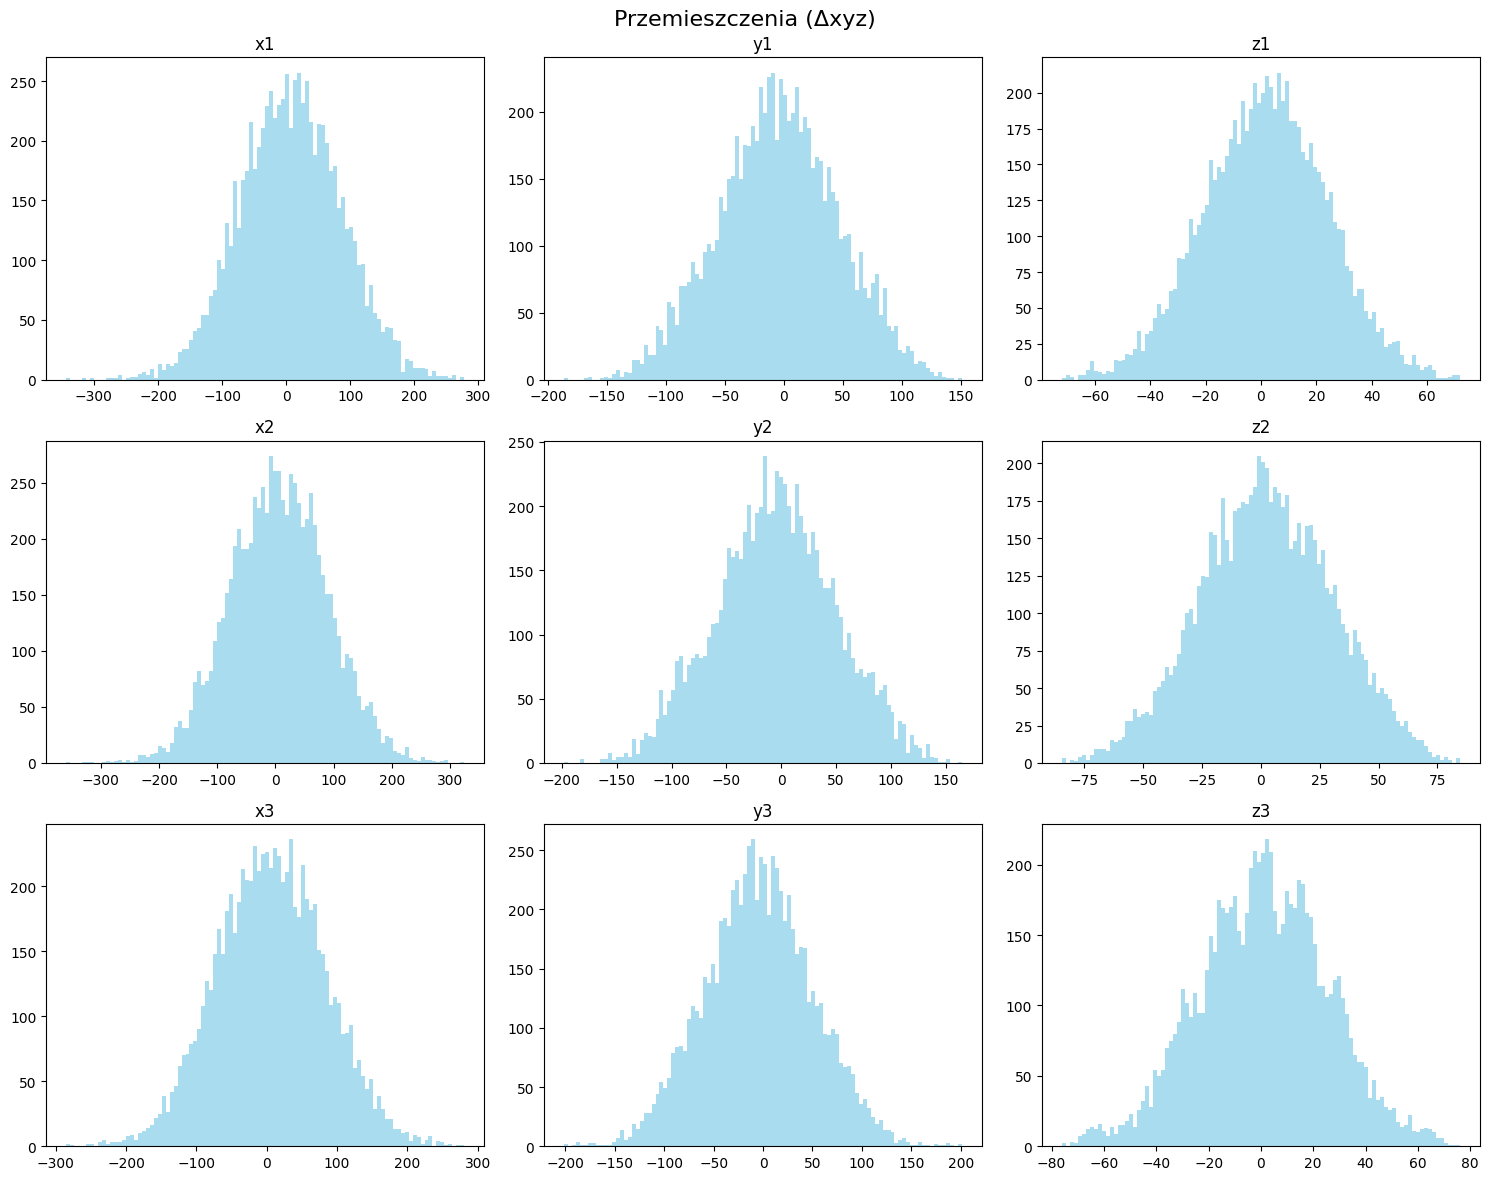

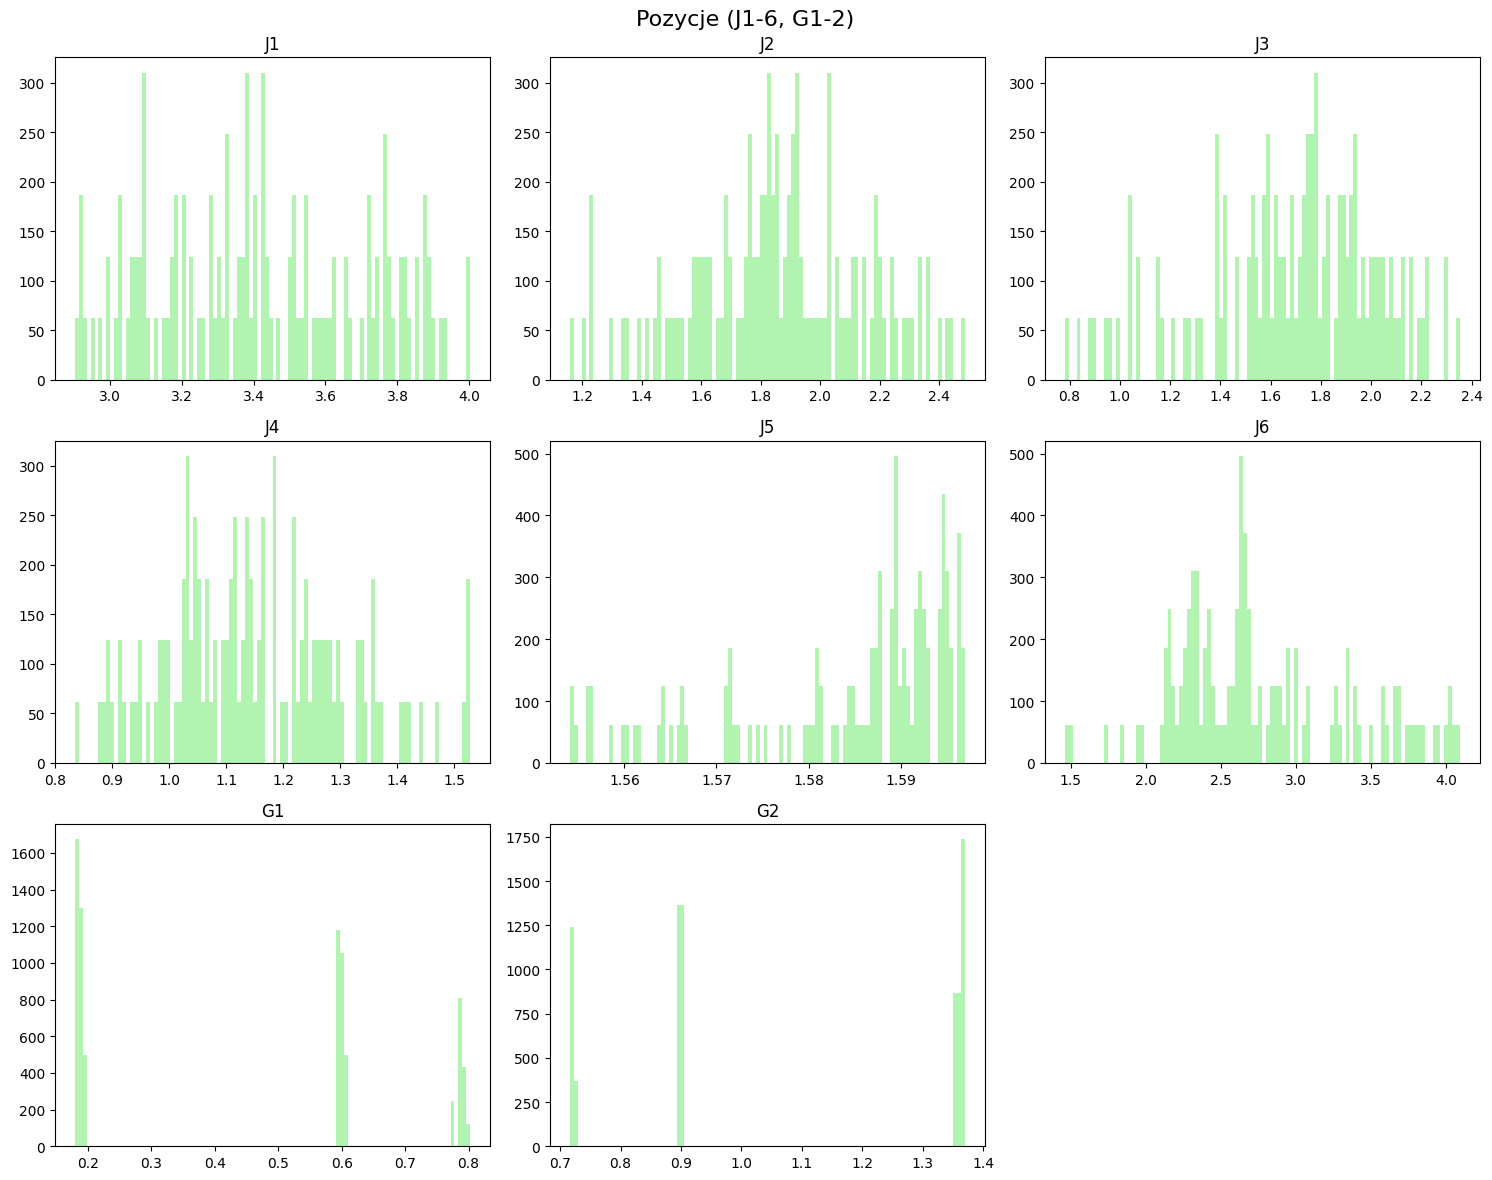

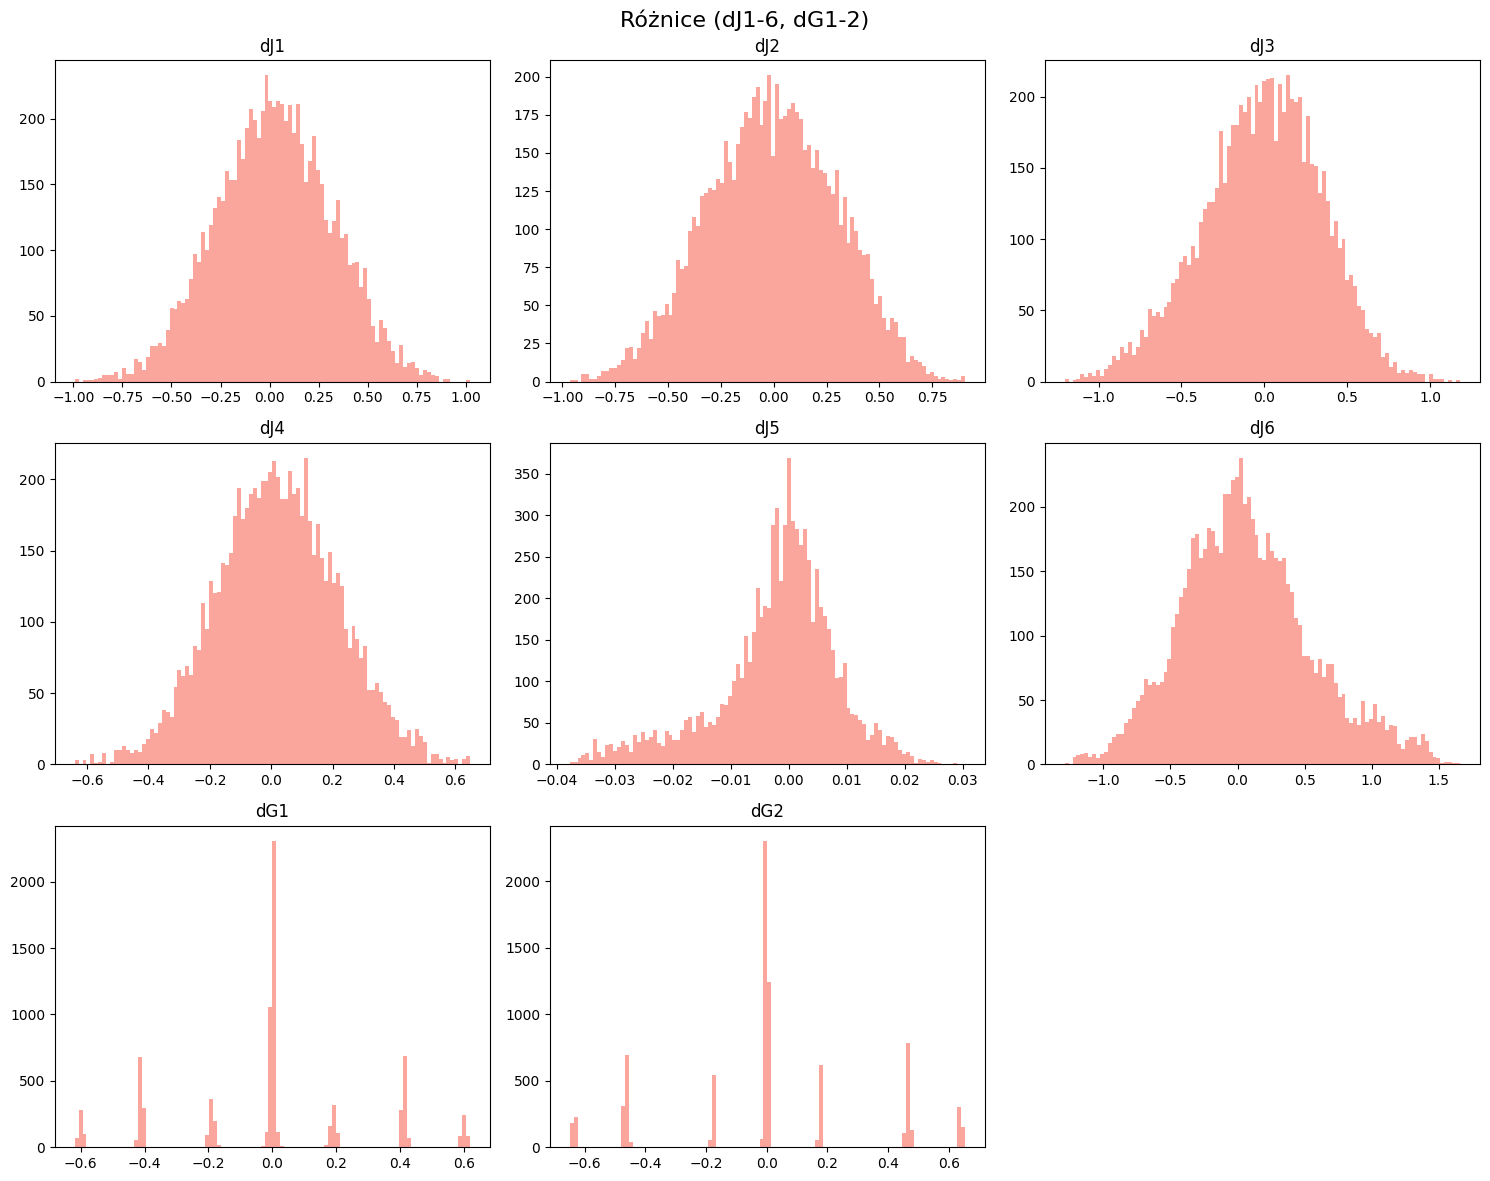

In [148]:
# 1. Histogramy przemieszczeń (3x3Δxyz -> 9 wykresów)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Przemieszczenia (Δxyz)', fontsize=16)
for i, ax in enumerate(axes.flat):
    if i < 9:
        ax.hist(df.iloc[:, i], bins=100, color='skyblue', alpha=0.7)
        ax.set_title(df.columns[i])
plt.tight_layout()
plt.show()

# 2. Histogramy pozycji (J1-6 + G1-2 -> 8 wykresów)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Pozycje (J1-6, G1-2)', fontsize=16)
for i, ax in enumerate(axes.flat):
    if i < 8:
        ax.hist(df.iloc[:, 9 + i], bins=100, color='lightgreen', alpha=0.7)
        ax.set_title(df.columns[9 + i])
    else:
        ax.axis('off')  # Ukryj ostatni, pusty wykres
plt.tight_layout()
plt.show()

# 3. Histogramy różnic (dJ1-6 + dG1-2 -> 8 wykresów)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Różnice (dJ1-6, dG1-2)', fontsize=16)
for i, ax in enumerate(axes.flat):
    if i < 8:
        ax.hist(df.iloc[:, 17 + i], bins=100, color='salmon', alpha=0.7)
        ax.set_title(df.columns[17 + i])
    else:
        ax.axis('off')  # Ukryj ostatni, pusty wykres
plt.tight_layout()
plt.show()

# Tworzenie i Konfiguracja Modelu

Podstawowe parametry modelu

In [13]:
OUTPUTS_PATH = Path("/mnt/d/Backup/MAGISTERSKIE/outputs/MODEL/model_outputs")
MODEL_PATH = Path("/mnt/d/Backup/MAGISTERSKIE/outputs/MODEL/model")

OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)

input_shape = x_train.shape[-1]
output_shape = y_train.shape[-1]
print(f"input_shape: {input_shape}, output_shape: {output_shape}")

input_shape: 17, output_shape: 8


Lista callback do uczenia

In [100]:
callbacks_list = [
  tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_PATH)+'/saved_model.keras',
    monitor='val_loss',
    save_best_only=True
  ),
  tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    verbose=True
  ),
  tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
  )]

## Wariant 1 - Budowanie modelu ręcznie

Parametry modelu

In [44]:
neurons = 320
dropout = 0.1

In [45]:
"""
inputs = tf.keras.Input(shape=(input_shape,))

# augmentacja
#x = tf.keras.layers.GaussianNoise(0.1)(inputs)

x = tf.keras.layers.Dense(neurons, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(dropout/2)(x)

# Pierwszy blok residual
x_skip = x
x = tf.keras.layers.Dense(neurons*2, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(dropout)(x)
x = tf.keras.layers.Dense(neurons, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Add()([x, x_skip])

# Drugi blok residual
x_skip = x
x = tf.keras.layers.Dense(neurons*2, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(dropout)(x)
x = tf.keras.layers.Dense(neurons, activation='relu', activity_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Add()([x, x_skip])

outputs_normalized = tf.keras.layers.Dense(output_shape, name='normalized_dense')(x)

outputs = tf.keras.layers.Normalization(
    mean=y_train_mean, 
    variance=y_train_variance, 
    invert=True, 
    name='denormalization'
)(outputs_normalized)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()
#""";

## Wariant 2 - Budowanie modelu za pomocą tunera

In [ ]:
"""
import keras_tuner as kt

input_shape = x_train.shape[-1]
output_shape = y_train.shape[-1]

def build_model(hp):
    hp: kt.HyperParameters
    
    num_blocks = hp.Int('num_blocks', min_value=4, max_value=8, step=1)
    neurons = hp.Int('neurons', min_value=64, max_value=640, step=64)
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')
    
    inputs = tf.keras.Input(shape=(input_shape,))
    x = inputs
    x = tf.keras.layers.Dense(neurons, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    
    for i in range(num_blocks):
        x_skip = x
        x = tf.keras.layers.Dense(neurons*2, activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(0.1)(x)
        x = tf.keras.layers.Dense(neurons, activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Add()([x, x_skip])
    
    outputs_normalized = tf.keras.layers.Dense(output_shape, name='normalized_dense')(x)
    outputs = tf.keras.layers.Normalization(mean=y_train_mean, variance=y_train_variance, invert=True, name='denormalization')(outputs_normalized)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=16,
    executions_per_trial=1,
    #directory='ktuner_dir',
    project_name='diff_pred_tuning'
)

tuner.search(x_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=callbacks_list)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best number of blocks:", best_hp.get('num_blocks'))
print("Best neurons:", best_hp.get('neurons'))
print("Best learning rate:", best_hp.get('learning_rate'))

play_sound()
#"""

Trial 16 Complete [00h 00m 26s]
val_loss: 0.10651502758264542

Best val_loss So Far: 0.0014951841440051794
Total elapsed time: 00h 49m 40s
Best number of blocks: 7
Best neurons: 128
Best learning rate: 0.005125626297102766


Tworzenie szkieletu modelu i zapisanie do pliku

In [ ]:
# model = build_model(best_hp)
# model.save(str(MODEL_PATH)+"/new_model_tuned.keras")

# Proces Uczenia

Odczytanie znalezionego szkieletu modelu

In [101]:
model = tf.keras.models.load_model(MODEL_PATH / "new_model_tuned.keras")

/home/ruszczka/projekty/test_files/.venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 126 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
"""
base_learning_rate = 1e-2
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    base_learning_rate,
    decay_steps=2318,
    decay_rate=0.8,
    staircase=True)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss= tf.keras.losses.MeanSquaredError(),
              metrics = [tf.keras.metrics.RootMeanSquaredError()])
#""";

Proces uczenia

In [102]:
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=256,
    callbacks=callbacks_list
)
play_sound()

Epoch 1/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 1.1698 - root_mean_squared_error: 1.0409 - val_loss: 0.4359 - val_root_mean_squared_error: 0.6603 - learning_rate: 0.0051
Epoch 2/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0751 - root_mean_squared_error: 0.2736 - val_loss: 0.1659 - val_root_mean_squared_error: 0.4073 - learning_rate: 0.0051
Epoch 3/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0457 - root_mean_squared_error: 0.2138 - val_loss: 0.0852 - val_root_mean_squared_error: 0.2920 - learning_rate: 0.0051
Epoch 4/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0367 - root_mean_squared_error: 0.1915 - val_loss: 0.0618 - val_root_mean_squared_error: 0.2486 - learning_rate: 0.0051
Epoch 5/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0314 - root_mean_squared_error: 0.1771 - val_loss: 0.0548 - val_root_mean_squared_error: 0.2341 - learning_rate: 0.0051
Epoch 6/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0287 - root_mean_squared_err

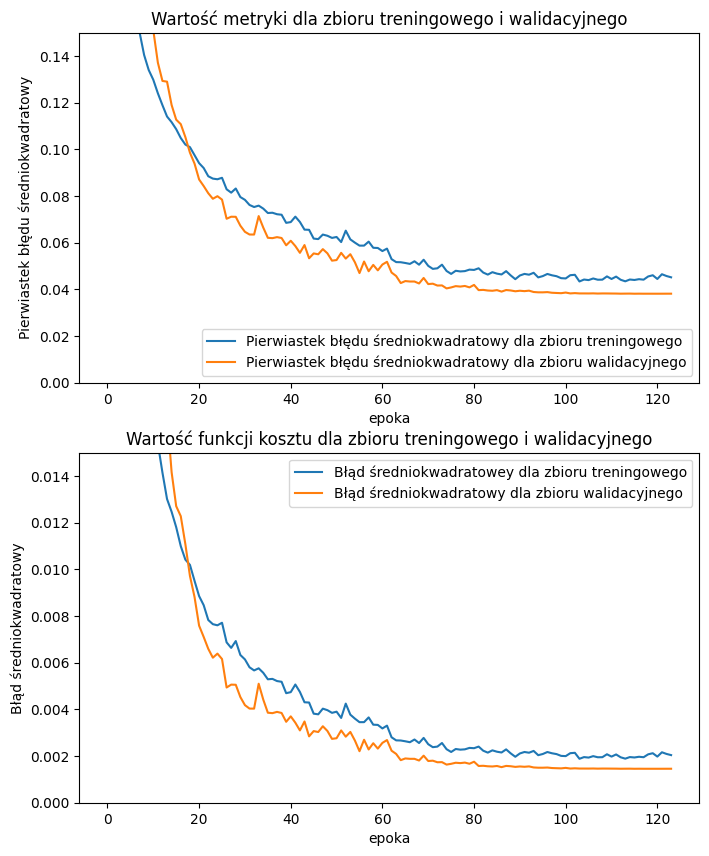

In [110]:
root_mean_squared_error = history.history['root_mean_squared_error']
val_root_mean_squared_error = history.history['val_root_mean_squared_error']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(root_mean_squared_error, label='Pierwiastek błędu średniokwadratowy dla zbioru treningowego')
plt.plot(val_root_mean_squared_error, label='Pierwiastek błędu średniokwadratowy dla zbioru walidacyjnego')
plt.legend(loc='lower right')
plt.ylabel('Pierwiastek błędu średniokwadratowy')
plt.ylim(0.00,0.15)
plt.title('Wartość metryki dla zbioru treningowego i walidacyjnego')
plt.xlabel('epoka')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Błąd średniokwadratowey dla zbioru treningowego')
plt.plot(val_loss, label='Błąd średniokwadratowy dla zbioru walidacyjnego')
plt.legend(loc='upper right')
plt.ylabel('Błąd średniokwadratowy')
plt.ylim(0.000,0.015)
plt.title('Wartość funkcji kosztu dla zbioru treningowego i walidacyjnego')
plt.xlabel('epoka')
plt.savefig(str(OUTPUTS_PATH)+'/fig.png')

In [104]:
model.evaluate(x=x_test, y=y_test, batch_size=256, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0017 - root_mean_squared_error: 0.0411


[0.0016849656822159886, 0.041048333048820496]

## Testowanie uzyskanego modelu

Zapisanie wyników predykcji

In [105]:
model = tf.keras.models.load_model(str(MODEL_PATH)+'/saved_model.keras')

In [106]:
result = model.predict(x=x_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


Wyświetlenie błędów na poszczególnych przegubach

In [107]:
diff_test = np.rad2deg(np.mean(np.abs(result-y_test), axis=0))

joints_error_dict = dict(zip(df.columns[17:], diff_test))
for joint, error in joints_error_dict.items():
    print(f"{joint}: {error:.2f} stopni")

dJ1: 0.88 stopni
dJ2: 0.95 stopni
dJ3: 1.62 stopni
dJ4: 1.19 stopni
dJ5: 0.11 stopni
dJ6: 2.96 stopni
dG1: 1.84 stopni
dG2: 2.01 stopni


Wyświetlenie średniej i mediane błędu absolutnego

In [108]:
mean_test = np.rad2deg(np.mean(np.abs(result-y_test)))
median_test = np.rad2deg(np.median(np.abs(result-y_test)))

print(f"Średnia: {mean_test:.2f} stopni")
print(f"Mediana: {median_test:.2f} stopni")

Średnia: 1.44 stopni
Mediana: 0.91 stopni


## Zapisanie wyników do pliku .csv

In [34]:
cols = [ 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'G1', 'G2',
        'dJ1', 'dJ2', 'dJ3', 'dJ4', 'dJ5', 'dJ6', 'dG1', 'dG2',
        'pred_dJ1', 'pred_dJ2', 'pred_dJ3', 'pred_dJ4', 'pred_dJ5', 'pred_dJ6', 'pred_dG1', 'pred_dG2']

In [38]:
print(result.shape)
print(x_test[:,9:].shape)
print(y_test.shape)

(782, 8)
(782, 8)
(782, 8)


Zapisanie wyników do testowania na robocie

In [36]:
wyniki = pd.concat([pd.DataFrame(x_test[:,9:]*x_train_std[9:]+x_train_mean[9:], columns=cols[:8]),  # Pozycja początkowa
                    pd.DataFrame(y_test, columns=cols[8:16]),                                       # Różnica faktyczna
                    pd.DataFrame(result, columns=cols[16:])], axis=1)                               # Różnica przewidywana
wyniki.to_csv(str(OUTPUTS_PATH)+"/wyniki.csv", index=False, header=True)

In [39]:
wyniki.head(5)

,J1,J2,J3,J4,J5,J6,G1,G2,dJ1,dJ2,...,dG1,dG2,pred_dJ1,pred_dJ2,pred_dJ3,pred_dJ4,pred_dJ5,pred_dJ6,pred_dG1,pred_dG2
0,3.372899,2.148666,1.541288,1.000734,1.589058,2.611842,0.189191,1.360128,-0.028587,0.636813,...,0.000000,0.005114,-0.011864,0.623765,-0.502945,-0.106792,0.000793,-0.054576,0.009216,-0.018527
1,3.703124,2.080287,1.302923,1.302162,1.573526,3.339668,0.189191,1.365241,-0.016800,-0.406606,...,0.005114,-0.005113,-0.038709,-0.386642,0.484367,-0.093092,0.006809,-0.317647,0.050840,-0.030353
2,3.899750,1.891317,1.515663,1.279583,1.580812,3.006794,0.184077,1.370354,0.498264,0.379464,...,-0.005114,0.015340,0.484224,0.371117,-0.527454,0.152126,-0.005861,0.329079,0.075723,-0.064212
3,3.176253,1.778988,1.728359,1.187161,1.592030,2.414965,0.189191,1.355014,-0.138788,-0.118281,...,0.005114,-0.015340,-0.125987,-0.118301,0.236888,-0.129300,-0.000097,0.115236,-0.015175,0.010857
4,3.279755,2.024585,1.324847,1.343148,1.590640,2.515393,0.787442,0.720970,0.187421,0.074507,...,0.194304,-0.178964,0.158795,0.046909,-0.248524,0.208094,0.009037,-0.490447,0.198426,-0.196520


In [62]:
print("Mniejszy od 1 stopnia:")
for col in cols[8:16]:
    print(f"{col}: {np.sum(np.abs(np.rad2deg(wyniki[col])-np.rad2deg(wyniki['pred_'+col]))<1)} / {len(wyniki)} {np.sum(np.abs(np.rad2deg(wyniki[col])-np.rad2deg(wyniki['pred_'+col]))<1)/len(wyniki)*100:.2f}%")

Mniejszy od 1 stopnia:
dJ1: 536 / 782 68.54%
dJ2: 544 / 782 69.57%
dJ3: 385 / 782 49.23%
dJ4: 457 / 782 58.44%
dJ5: 782 / 782 100.00%
dJ6: 285 / 782 36.45%
dG1: 383 / 782 48.98%
dG2: 363 / 782 46.42%


In [86]:
do_pracy = pd.DataFrame({'nazwa': cols[8:16],
                         'średnia': [(np.rad2deg(np.mean(np.abs(wyniki[col]-wyniki['pred_'+col])))).round(2) for col in cols[8:16]],
                         'mediana': [(np.rad2deg(np.median(np.abs(wyniki[col]-wyniki['pred_'+col])))).round(2) for col in cols[8:16]],
                         'odchylenie_standardowe': [(np.rad2deg(np.std(np.abs(wyniki[col]-wyniki['pred_'+col])))).round(2) for col in cols[8:16]],
                         'mniejsze_od_1': [np.sum(np.abs(np.rad2deg(wyniki[col])-np.rad2deg(wyniki['pred_'+col]))<1) for col in cols[8:16]],
                         'procent_mniejsze_od_1 [%]': [(np.sum(np.abs(np.rad2deg(wyniki[col])-np.rad2deg(wyniki['pred_'+col]))<1)/len(wyniki)*100).round(2) for col in cols[8:16]]}
                        )
do_pracy.head(8)
# skopiowanie ostatniego wiesza do schowka transponowana
do_pracy.iloc[-1].T.to_clipboard()
#do_pracy.iloc[-1].to_clipboard()

nazwa                          dG2
średnia                       1.53
mediana                       1.07
odchylenie_standardowe        1.66
mniejsze_od_1                  363
procent_mniejsze_od_1 [%]    46.42
Name: 7, dtype: object

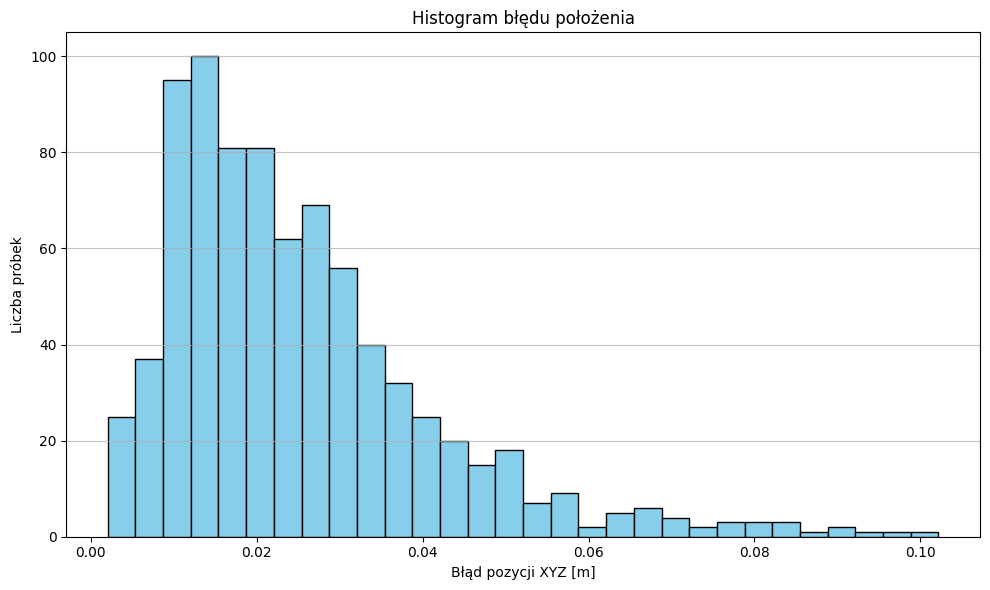

In [131]:
RESULT_PATH = Path("/mnt/c/Users/rados/downloads")
df_wyniki = pd.read_csv(str(RESULT_PATH)+'/wyniki_vert_converted.csv')

# Obliczenie błędów i konwersja jednostek na metry (dzielenie przez 1000 zakłada, że dane bazowe są w mm)
df_wyniki['error_x_m'] = (df_wyniki['x_to_predicted'] - df_wyniki['x_to_ground_truth'])
df_wyniki['error_y_m'] = (df_wyniki['y_to_predicted'] - df_wyniki['y_to_ground_truth'])
df_wyniki['error_z_m'] = (df_wyniki['z_to_predicted'] - df_wyniki['z_to_ground_truth'])

# Obliczenie całkowitego błędu położenia w metrach
df_wyniki['error_magnitude_m'] = np.sqrt(df_wyniki[['error_x_m', 'error_y_m', 'error_z_m']].pow(2).sum(axis=1))

# Wyświetlenie histogramu błędu położenia w metrach
plt.figure(figsize=(10, 6))
plt.hist(df_wyniki['error_magnitude_m'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram błędu położenia')
plt.xlabel('Błąd pozycji XYZ [m]')
plt.ylabel('Liczba próbek')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Histogram otrzymanych wyników

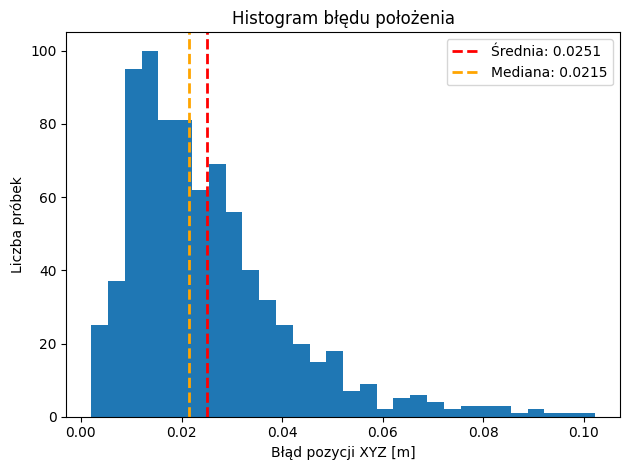

In [130]:
RESULT_PATH = Path("/mnt/c/Users/rados/downloads")

# Załdowanie danych i obliczenie błędów
df_wyniki = pd.read_csv(str(RESULT_PATH)+'/wyniki_vert_converted.csv')
df_wyniki['error_x'] = df_wyniki['x_to_predicted'] - df_wyniki['x_to_ground_truth']
df_wyniki['error_y'] = df_wyniki['y_to_predicted'] - df_wyniki['y_to_ground_truth']
df_wyniki['error_z'] = df_wyniki['z_to_predicted'] - df_wyniki['z_to_ground_truth']
df_wyniki['error_magnitude'] = np.sqrt(df_wyniki[['error_x', 'error_y', 'error_z']].pow(2).sum(axis=1))
mean_error = df_wyniki['error_magnitude'].mean()
median_error = df_wyniki['error_magnitude'].median()

# Wyświetlenie histogramu błędu położenia
plt.figure()
plt.hist(df_wyniki['error_magnitude'], bins=30)
plt.axvline(mean_error, linestyle='--', linewidth=2, label=f'Średnia: {mean_error:.4f}', color='red')
plt.axvline(median_error, linestyle='--', linewidth=2, label=f'Mediana: {median_error:.4f}', color='orange')
plt.title('Histogram błędu położenia')
plt.xlabel('Błąd pozycji XYZ [m]')
plt.ylabel('Liczba próbek')
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
print(df.columns)

Index(['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'J1', 'J2', 'J3',
       'J4', 'J5', 'J6', 'G1', 'G2', 'dJ1', 'dJ2', 'dJ3', 'dJ4', 'dJ5', 'dJ6',
       'dG1', 'dG2'],
      dtype='object')
